# Visão Computacional e Deep Learning para Sensoriamento Remoto com Python


#Capítulo 22 - Detecção de defeitos em imagens térmicas de painéis solares com a YOLOv8

## YOLOv8

YOLOv8 é o mais novo modelo YOLO de última geração que pode ser usado para tarefas de detecção de objetos, classificação de imagens e segmentação de instâncias. O YOLOv8 foi desenvolvido pela Ultralytics, que também criou o modelo YOLOv5 influente e definidor do setor. O YOLOv8 inclui inúmeras mudanças e melhorias na arquitetura e na experiência do desenvolvedor em relação ao YOLOv5.

### Versões

YOLOv8 oferece vários tamanhos de modelo para atender a diferentes cenários de implantação. Esses modelos incluem YOLOv8n, YOLOv8s, YOLOv8m, YOLOv8l e YOLOv8x. Por exemplo, se o modelo estiver sendo implantado em dispositivos de ponta, o YOLOv8n poderá ser escolhido.

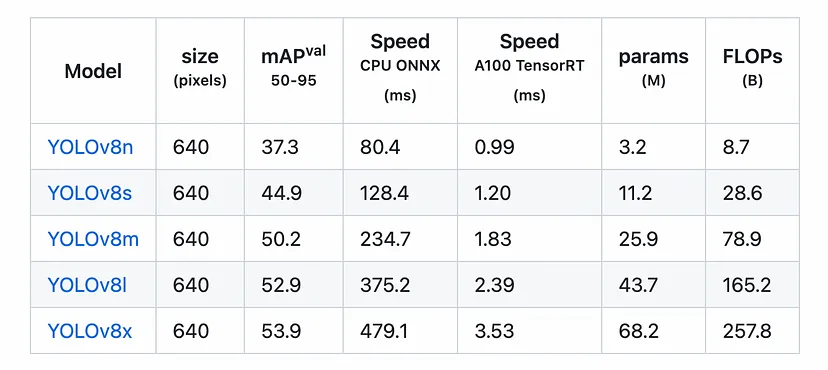

### Arquitetura e design de rede YOLOv8

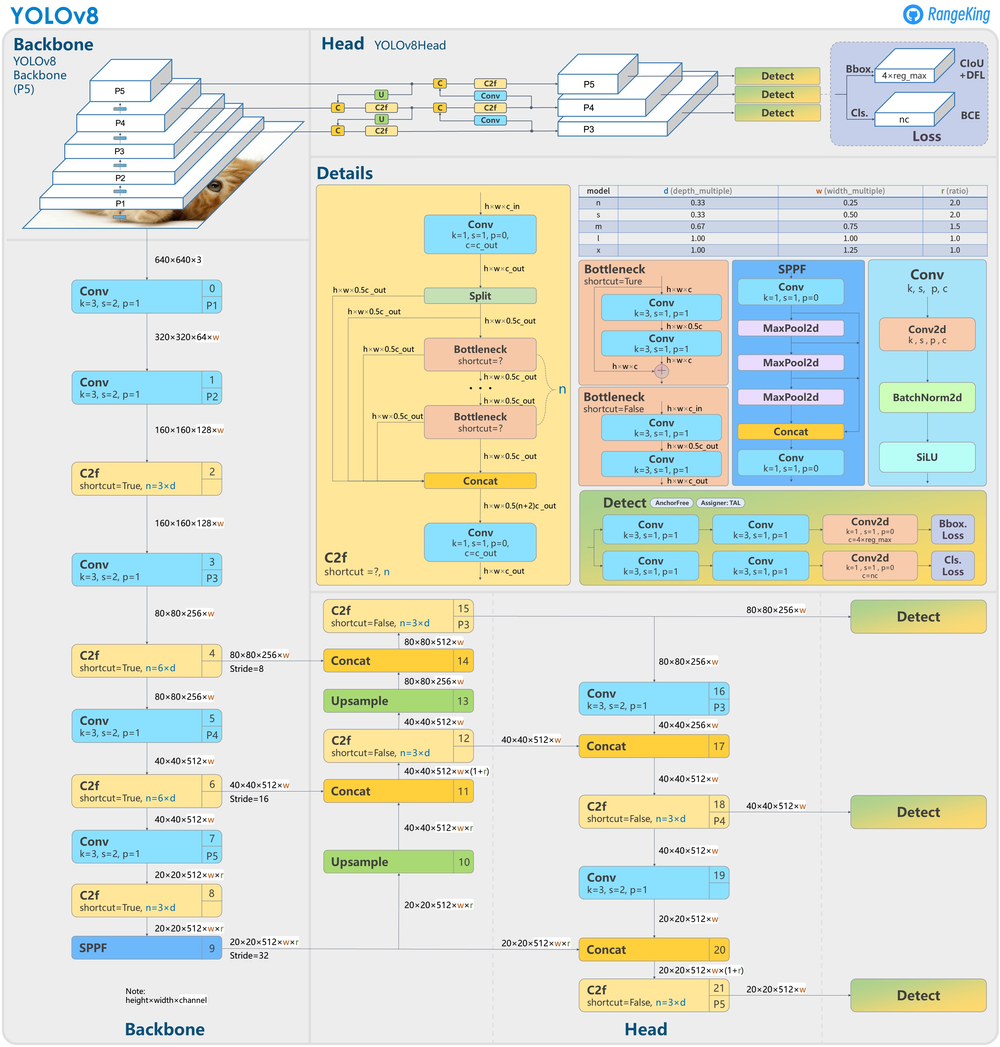

### Detecção Anchor Free

YOLOv8 é um modelo sem âncora. Isso significa que ele prevê diretamente o centro de um objeto, em vez do deslocamento de uma caixa de âncora conhecida.

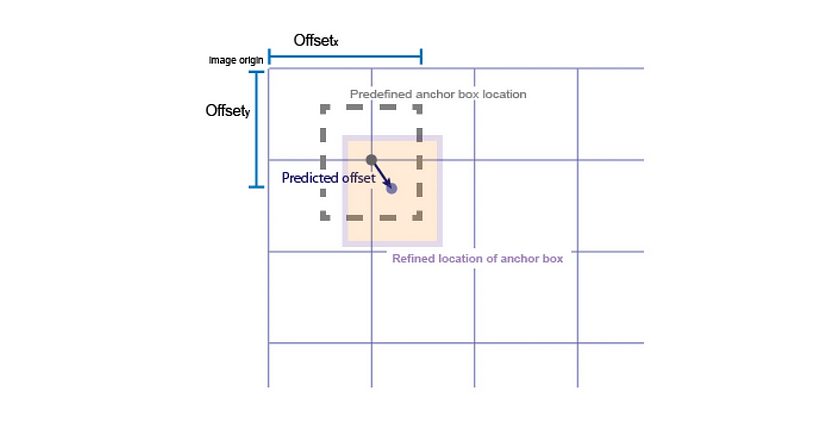

As caixas de âncora são um conjunto predefinido de caixas com alturas e larguras específicas, usadas para detectar classes de objetos com a escala e proporção desejadas. Eles são escolhidos com base no tamanho dos objetos no conjunto de dados de treinamento e são dispostos lado a lado na imagem durante a detecção.

A rede gera probabilidade e atributos como plano de fundo, IoU e deslocamentos para cada caixa lado a lado, que são usados para ajustar as caixas âncora. Várias caixas de âncora podem ser definidas para diferentes tamanhos de objetos, servindo como pontos de partida fixos para estimativas de caixas limite.

A vantagem da detecção sem âncora é que ela é mais flexível e eficiente, pois não requer a especificação manual de caixas de âncora, o que pode ser difícil de escolher e pode levar a resultados abaixo do ideal em modelos YOLO anteriores, como v1 e v2.

A detecção sem âncora reduz o número de previsões de caixa, o que acelera a supressão não máxima (NMS), uma etapa complicada de pós-processamento que analisa as detecções de candidatos após a inferência.

### Novas Convoluções

O primeiro 6x6 conv da haste foi substituído por 3x3, o bloco de construção principal foi alterado e C2f substituiu C3 . O módulo está resumido na figura abaixo, onde “f” é o número de funcionalidades, “e” é a taxa de expansão e CBS é um bloco composto por um Conv, um BatchNorm e um SiLU posteriormente.

No C2f, todas as saídas do Gargalo (nome sofisticado para duas conversões 3x3 com conexões residuais) são concatenadas. Enquanto em C3 foi utilizada apenas a saída do último Gargalo.

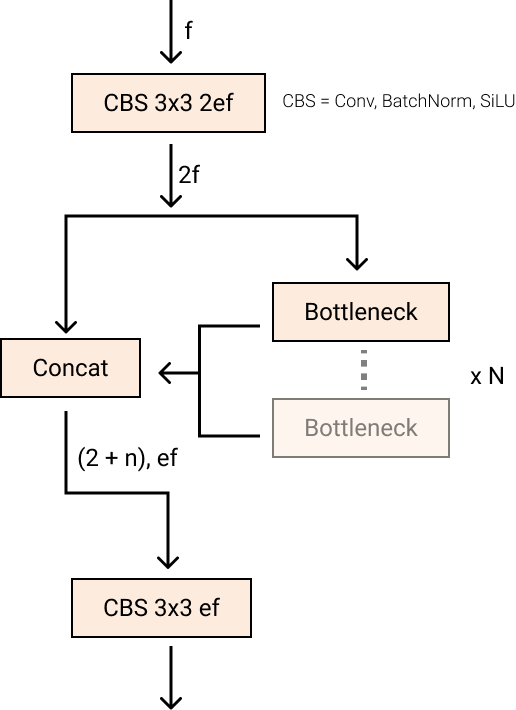

O gargalo é o mesmo do YOLOv5, mas o tamanho do kernel da primeira conversão foi alterado de 1x1 para 3x3. A partir dessas informações, podemos perceber que o YOLOv8 está começando a reverter para o bloco ResNet definido em 2015.

No Neck, os recursos são concatenados diretamente sem forçar as mesmas dimensões do canal. Isso reduz a contagem de parâmetros e o tamanho geral dos tensores.

### Mosaic Data Augmentation

A pesquisa de aprendizagem profunda tende a se concentrar na arquitetura do modelo, mas a rotina de treinamento no YOLOv5 e YOLOv8 é uma parte essencial de seu sucesso.

YOLOv8 aumenta imagens durante o treinamento online. Em cada época, o modelo vê uma variação ligeiramente diferente das imagens que lhe foram fornecidas.

O aumento de dados em mosaico foi introduzido pela primeira vez no YOLOv4 e é uma melhoria do aumento de dados CutMix.

Durante o treinamento, o YOLOv8 faz muitos acréscimos nas imagens de treinamento. Um desses aumentos é o aumento de dados em mosaico.
O aumento de dados em mosaico é uma técnica de aumento simples na qual quatro imagens diferentes são unidas e inseridas no modelo como entrada. Isso faz com que o modelo aprenda os objetos reais em diferentes posições e em oclusão parcial.

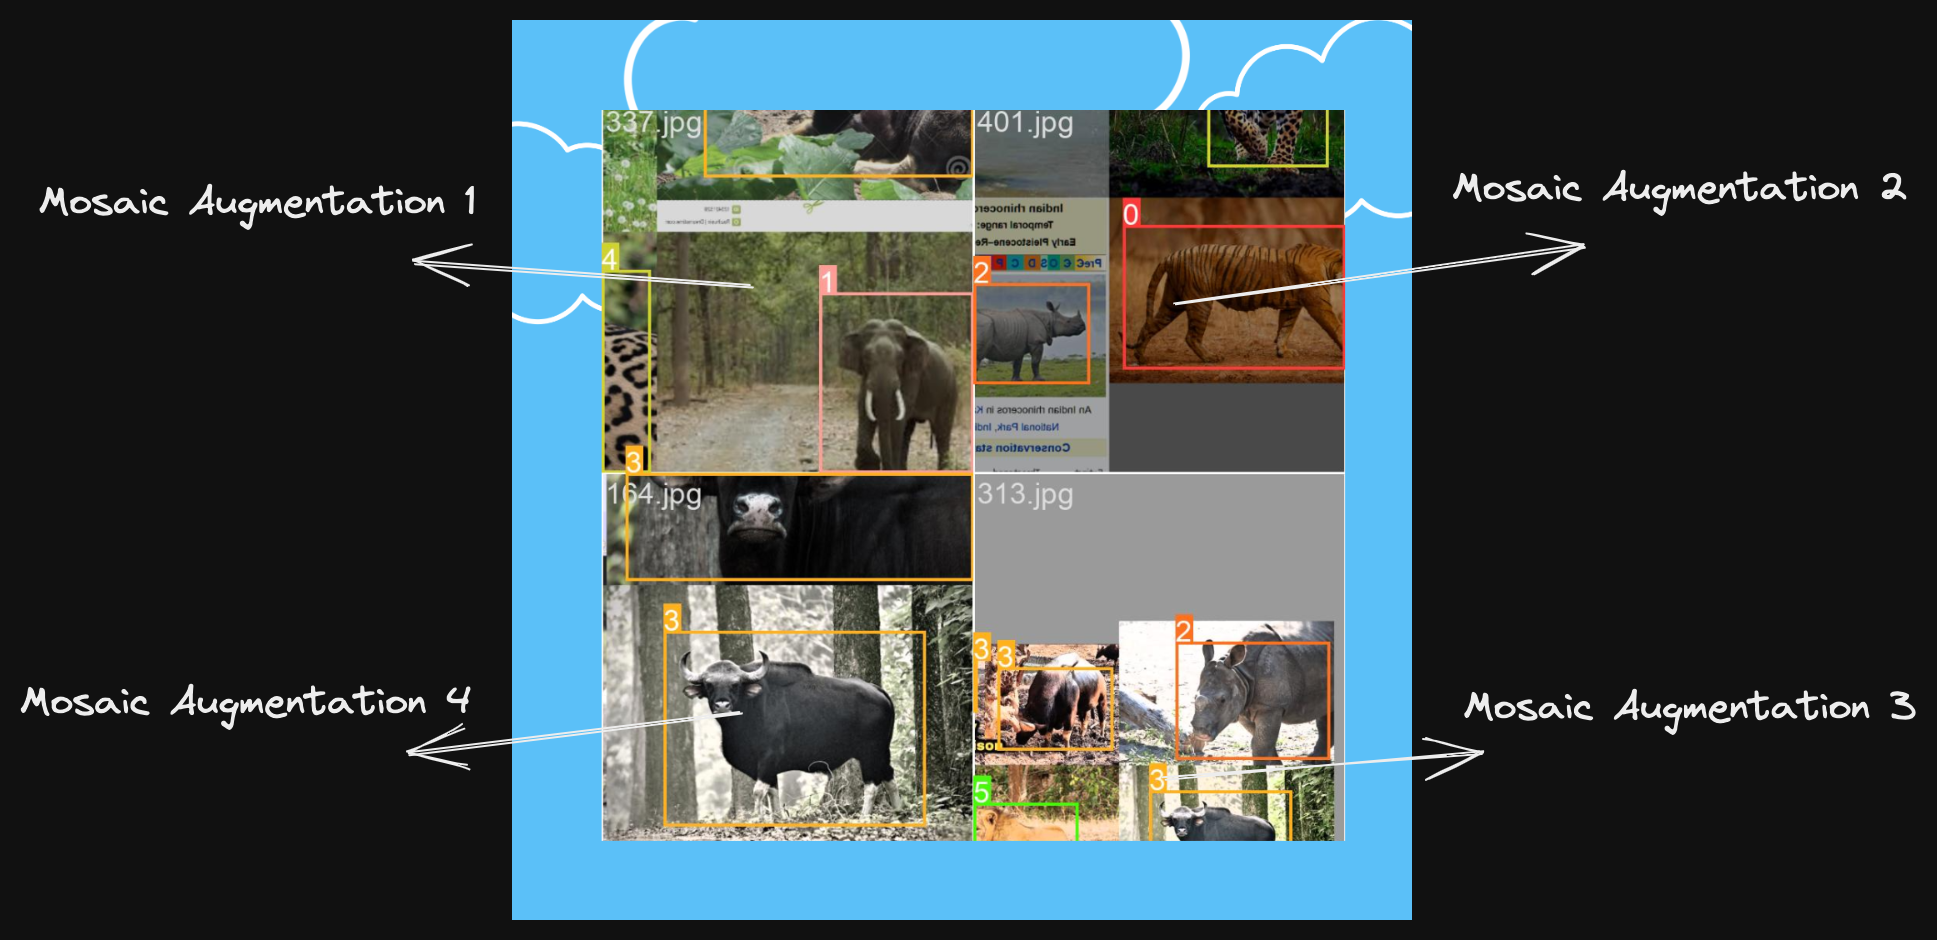

Foi demonstrado que a execução do aumento de dados do mosaico reduz o desempenho, por isso foi alterado nas últimas 10 épocas.

### Comparação

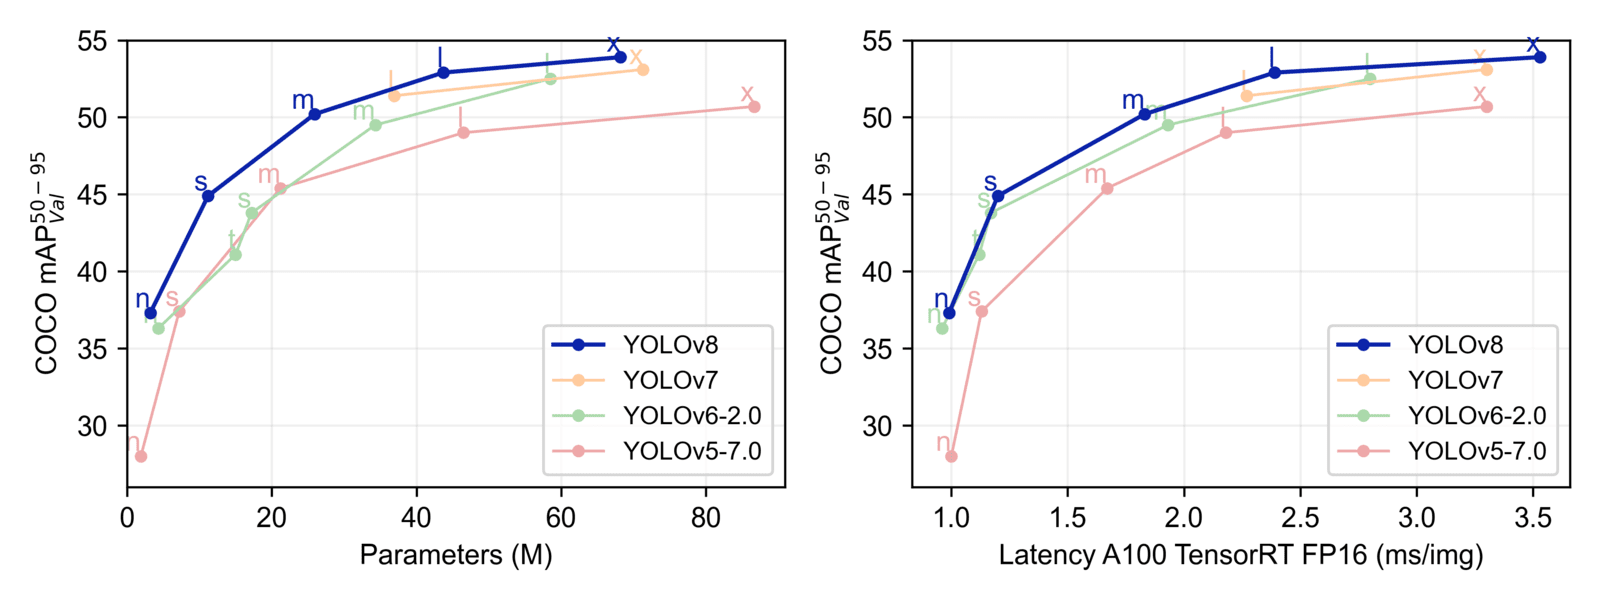

## Implementação da YOLOv8

Vamos iniciar conectando o Google Drive e importando as bibliotecas necessárias:

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
from matplotlib import pyplot as plt
import cv2
import os
import json
import math
import pandas as pd
from skimage import io
from skimage.io import imsave
from sklearn import model_selection
import os
import shutil
import json
import ast
import numpy as np
from tqdm import tqdm
import pandas as  pd
import seaborn as sns
import xml.etree.ElementTree as ET

Vamos definir os caminhos das imagens e labels para treinamento, validação e teste:

In [3]:
path_imgs_train = '/content/drive/MyDrive/Datasets/SolarPanelDefects/train/images'
path_labels_train = '/content/drive/MyDrive/Datasets/SolarPanelDefects/train/labels'
path_imgs_test = '/content/drive/MyDrive/Datasets/SolarPanelDefects/test/images'
path_labels_test = '/content/drive/MyDrive/Datasets/SolarPanelDefects/test/labels'
path_imgs_valid = '/content/drive/MyDrive/Datasets/SolarPanelDefects/valid/images'
path_labels_valid = '/content/drive/MyDrive/Datasets/SolarPanelDefects/valid/labels'

Agora, listamos as imagens de treinamento e plotamos um exemplo:

In [4]:
images_files = [f for f in os.listdir(path_imgs_train)]

In [5]:
len(images_files)

335

In [6]:
os.path.splitext(images_files[0])

('20220526_125751_R_jpg.rf.e71eca6c2cb9fd0f3bfb4c99139b1351', '.jpg')

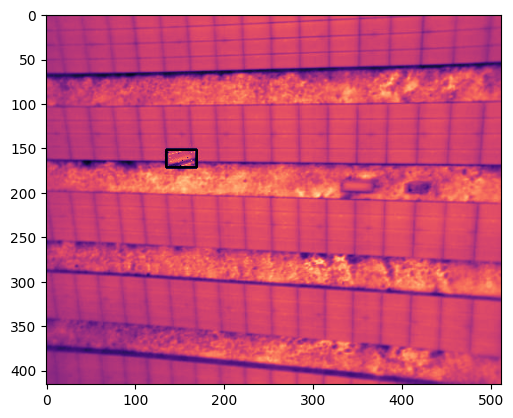

In [7]:
i = 3
image_path = os.path.join(path_imgs_train,images_files[i])
filename = os.path.splitext(images_files[i])[0]
label_path = os.path.join(path_labels_train,filename + '.txt')
img = cv2.imread(image_path)
dh, dw, _ = img.shape
img = (img[:,:,2] * 0.3) + (img[:,:,1] * 0.59) + (img[:,:,0] * 0.11)

fl = open(label_path, 'r')
data = fl.readlines()
fl.close()

for dt in data:

    # Split string to float
    _, x, y, w, h = map(float, dt.split(' '))

    l = int((x - w / 2) * dw)
    r = int((x + w / 2) * dw)
    t = int((y - h / 2) * dh)
    b = int((y + h / 2) * dh)

    if l < 0:
        l = 0
    if r > dw - 1:
        r = dw - 1
    if t < 0:
        t = 0
    if b > dh - 1:
        b = dh - 1

    cv2.rectangle(img, (l, t), (r, b), (0, 0, 0), 2)

plt.imshow(img, cmap='magma')
plt.show()

Depois de preparar os dados, vamos criar a estrutura de pastas onde organizaremos as imagens e os labels para a execução da YOLOv8:

In [8]:
!mkdir letuce_data
%cd letuce_data

/content/letuce_data


Criamos o diretório raiz, e depois criamos os diretórios de treinamento e validação para as imagens e labels:

In [9]:
!mkdir train
!mkdir valid
%cd train
!mkdir images
!mkdir labels
%cd ..
%cd valid
!mkdir images
!mkdir labels
%cd ..
%cd ..

/content/letuce_data/train
/content/letuce_data
/content/letuce_data/valid
/content/letuce_data
/content


Agora copiaremos os dados para estes diretórios:

In [10]:
OUTPUT_PATH = '/content/letuce_data/train/images'
for image_file in os.listdir(path_imgs_train):
  shutil.copyfile(
              os.path.join(path_imgs_train,image_file),
              os.path.join(OUTPUT_PATH,image_file)
          )

In [11]:
OUTPUT_PATH = '/content/letuce_data/train/labels'
for txt_file in os.listdir(path_labels_train):
  shutil.copyfile(
              os.path.join(path_labels_train,txt_file),
              os.path.join(OUTPUT_PATH,txt_file)
          )

In [12]:
OUTPUT_PATH = '/content/letuce_data/valid/images'
for image_file in os.listdir(path_imgs_valid):
  shutil.copyfile(
              os.path.join(path_imgs_valid,image_file),
              os.path.join(OUTPUT_PATH,image_file)
          )

In [13]:
OUTPUT_PATH = '/content/letuce_data/valid/labels'
for txt_file in os.listdir(path_labels_valid):
  shutil.copyfile(
              os.path.join(path_labels_valid,txt_file),
              os.path.join(OUTPUT_PATH,txt_file)
          )

In [14]:
f = open('/content/letuce_data/train/labels/'+os.listdir("/content/letuce_data/train/labels/")[0])
print(f.name)
for l in f:
    print(l)

/content/letuce_data/train/labels/20220526_125637_R_jpg.rf.3335e7c1891be9fc128414a28840d79d.txt
1 0.97265625 0.734375 0.0546875 0.040865384615384616

1 0.373046875 0.8509615384615384 0.07073974609375 0.048001802884615384

1 0.97265625 0.7992788461538461 0.0546875 0.036057692307692304

1 0.765625 0.9831730769230769 0.0859375 0.03365384615384615


A YOLOv8 está implementando na biblioteca da ultralytics, então só necessitamos instalar essa biblioteca:

In [15]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.8/644.8 kB 8.9 MB/s eta 0:00:00


Definimos o yaml com os caminhos dos dados e as classes que temos:

In [16]:
%%writefile /content/letuce_data/Letuce_detection.yaml

path: /content/letuce_data # dataset root dir
train: train/images/ # train images (relative to 'path')
val: valid/images/ # val images (relative to 'path')


nc: 3
names: ['ByPass_Diode', 'Dark_hot_spot', 'Light_hot_spot']

Writing /content/letuce_data/Letuce_detection.yaml


E podemos então importar a YOLOv8 e treiná-la por 50 épocas:

In [17]:
from ultralytics import YOLO

# Load a model
# model = YOLO("yolov8m.yaml")  # build a new model from scratch
model = YOLO("yolov8x.pt")  # load a pretrained model (recommended for training)

# Use the model
results = model.train(data="/content/letuce_data/Letuce_detection.yaml", epochs=50, imgsz=512)

100%|██████████| 131M/131M [00:00<00:00, 176MB/s]
Ultralytics YOLOv8.0.202 🚀 Python-3.10.12 torch-2.1.0+cu118 CUDA:0 (Tesla V100-SXM2-16GB, 16151MiB)
engine/trainer: task=detect, mode=train, model=yolov8x.pt, data=/content/letuce_data/Letuce_detection.yaml, epochs=50, patience=50, batch=16, imgsz=512, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, stream_buffer=False, line_width=None, visualize=False, augment=False, agnostic_nms=False, class

Aplicaremos a validação do modelo:

In [18]:
results = model.val()

Ultralytics YOLOv8.0.202 🚀 Python-3.10.12 torch-2.1.0+cu118 CUDA:0 (Tesla V100-SXM2-16GB, 16151MiB)
Model summary (fused): 268 layers, 68126457 parameters, 0 gradients, 257.4 GFLOPs
val: Scanning /content/letuce_data/valid/labels.cache... 19 images, 0 backgrounds, 0 corrupt: 100%|██████████| 19/19 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.61it/s]
                   all         19         34      0.278      0.201      0.271      0.098
          ByPass_Diode         19         19      0.667      0.526       0.66      0.279
         Dark_hot_spot         19          2          0          0          0          0
        Light_hot_spot         19         13      0.167     0.0769      0.152     0.0152
Speed: 0.2ms preprocess, 17.0ms inference, 0.0ms loss, 14.0ms postprocess per image
Results saved to runs/detect/train2


Assim podemos ver algumas métricas:

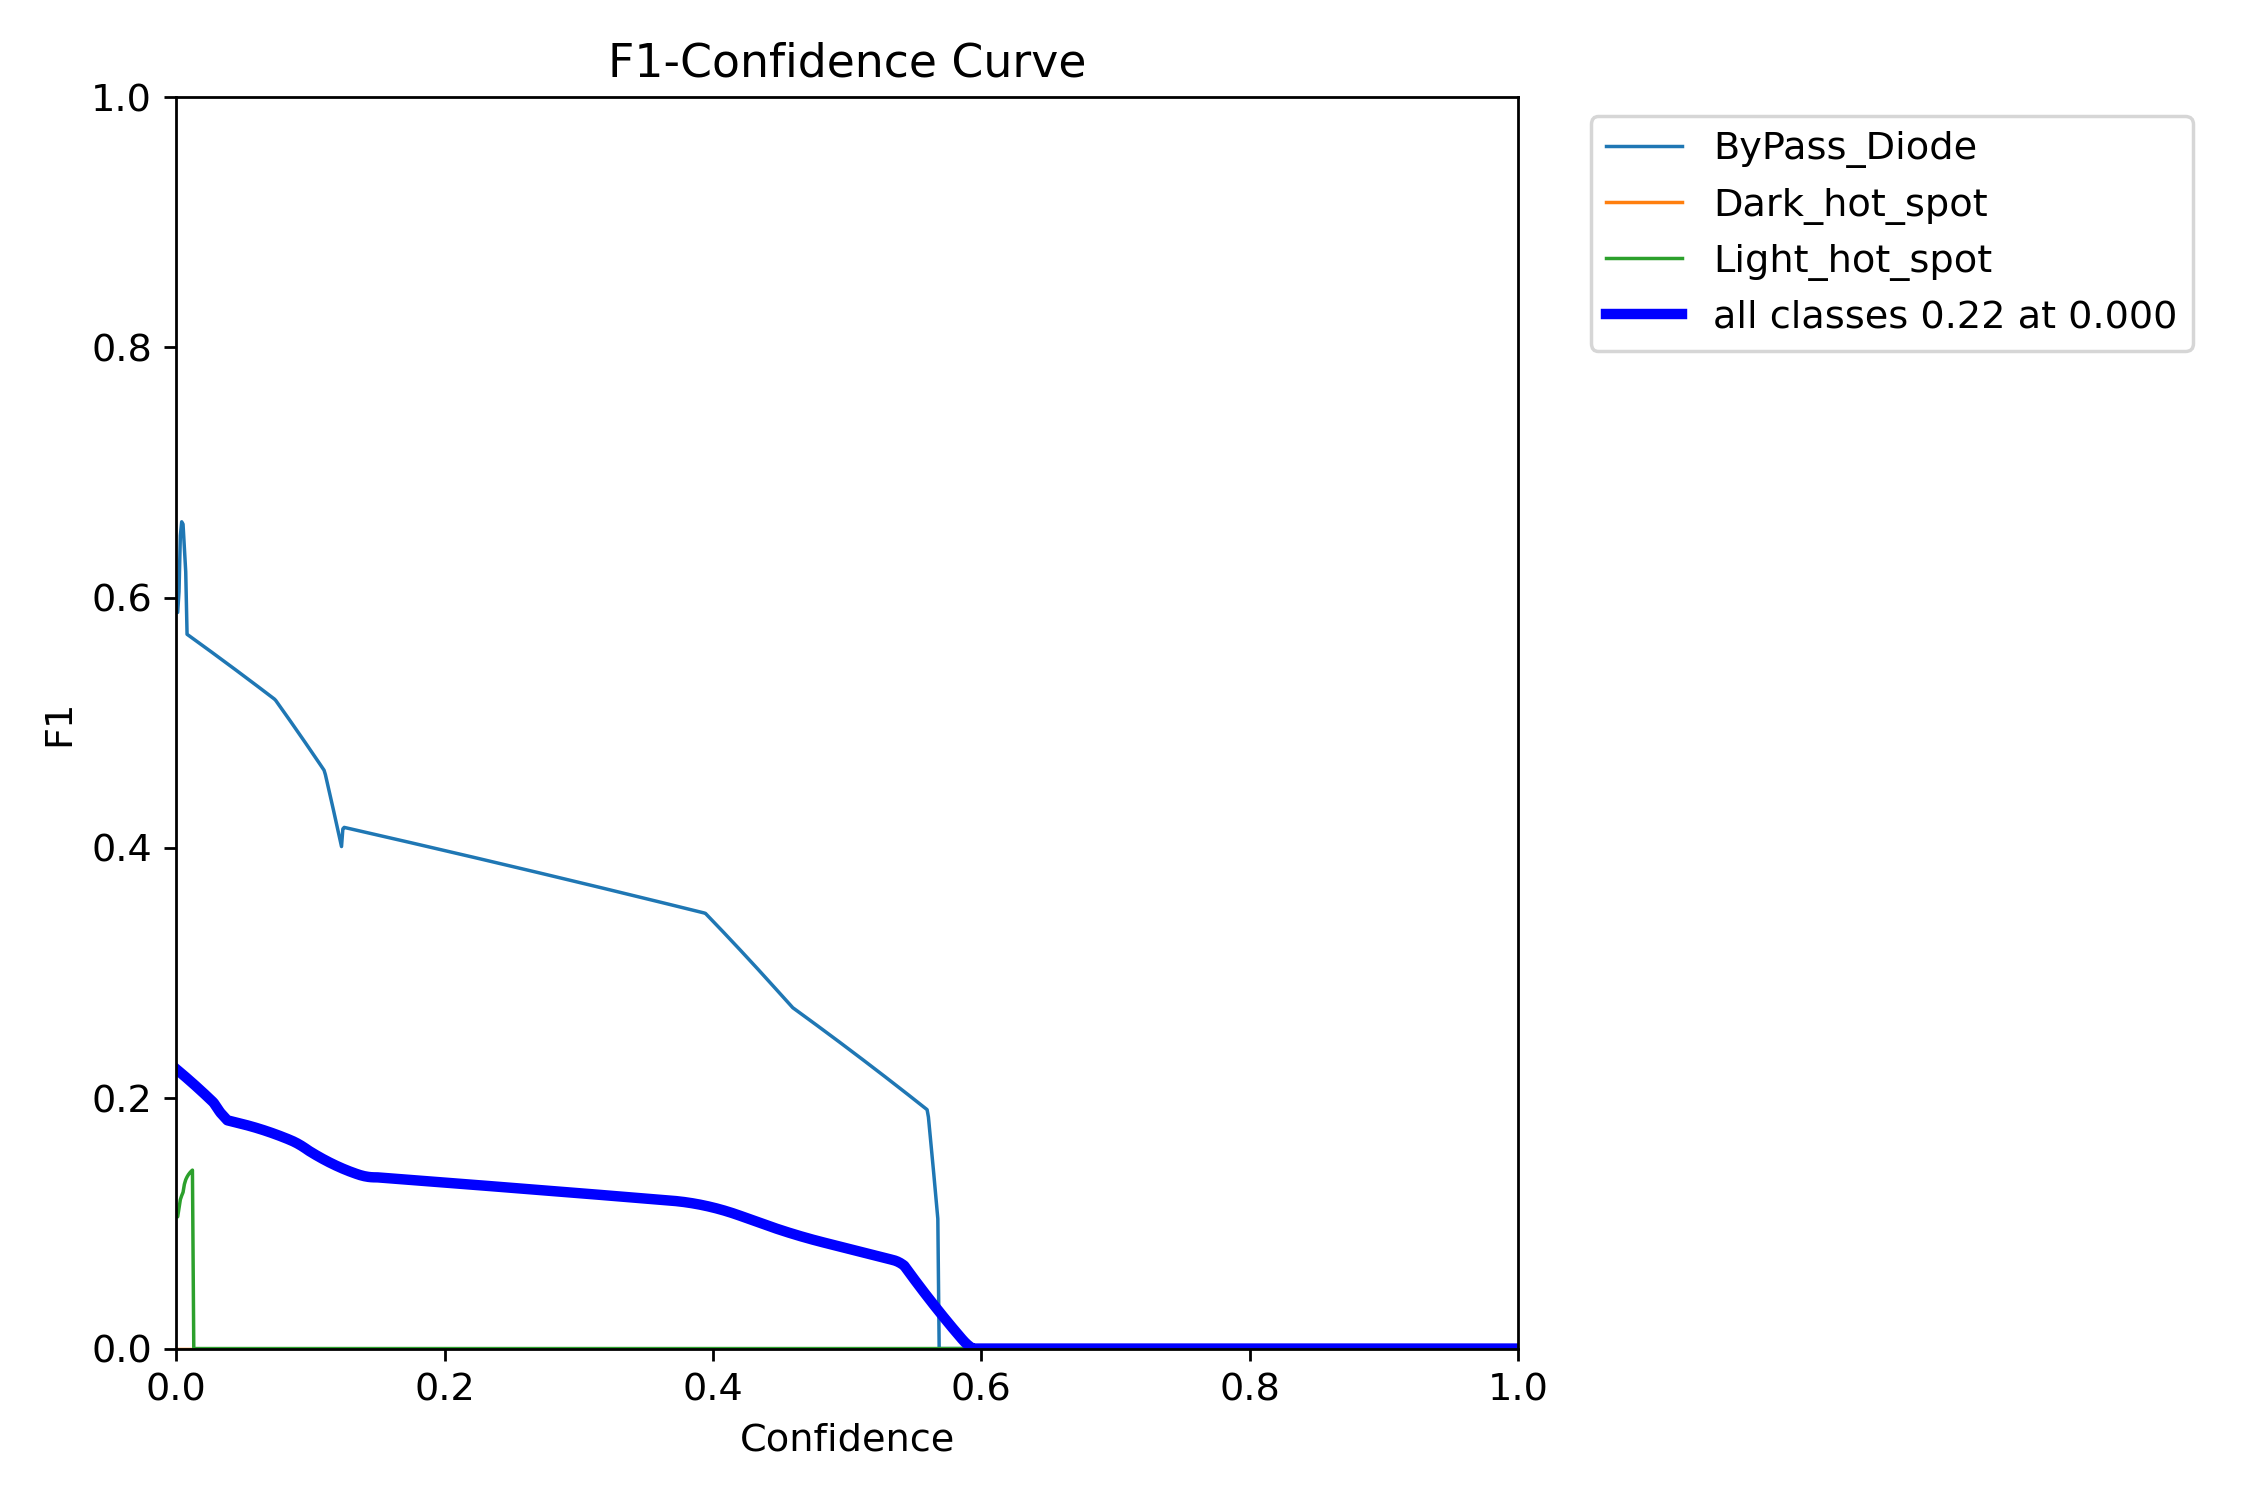

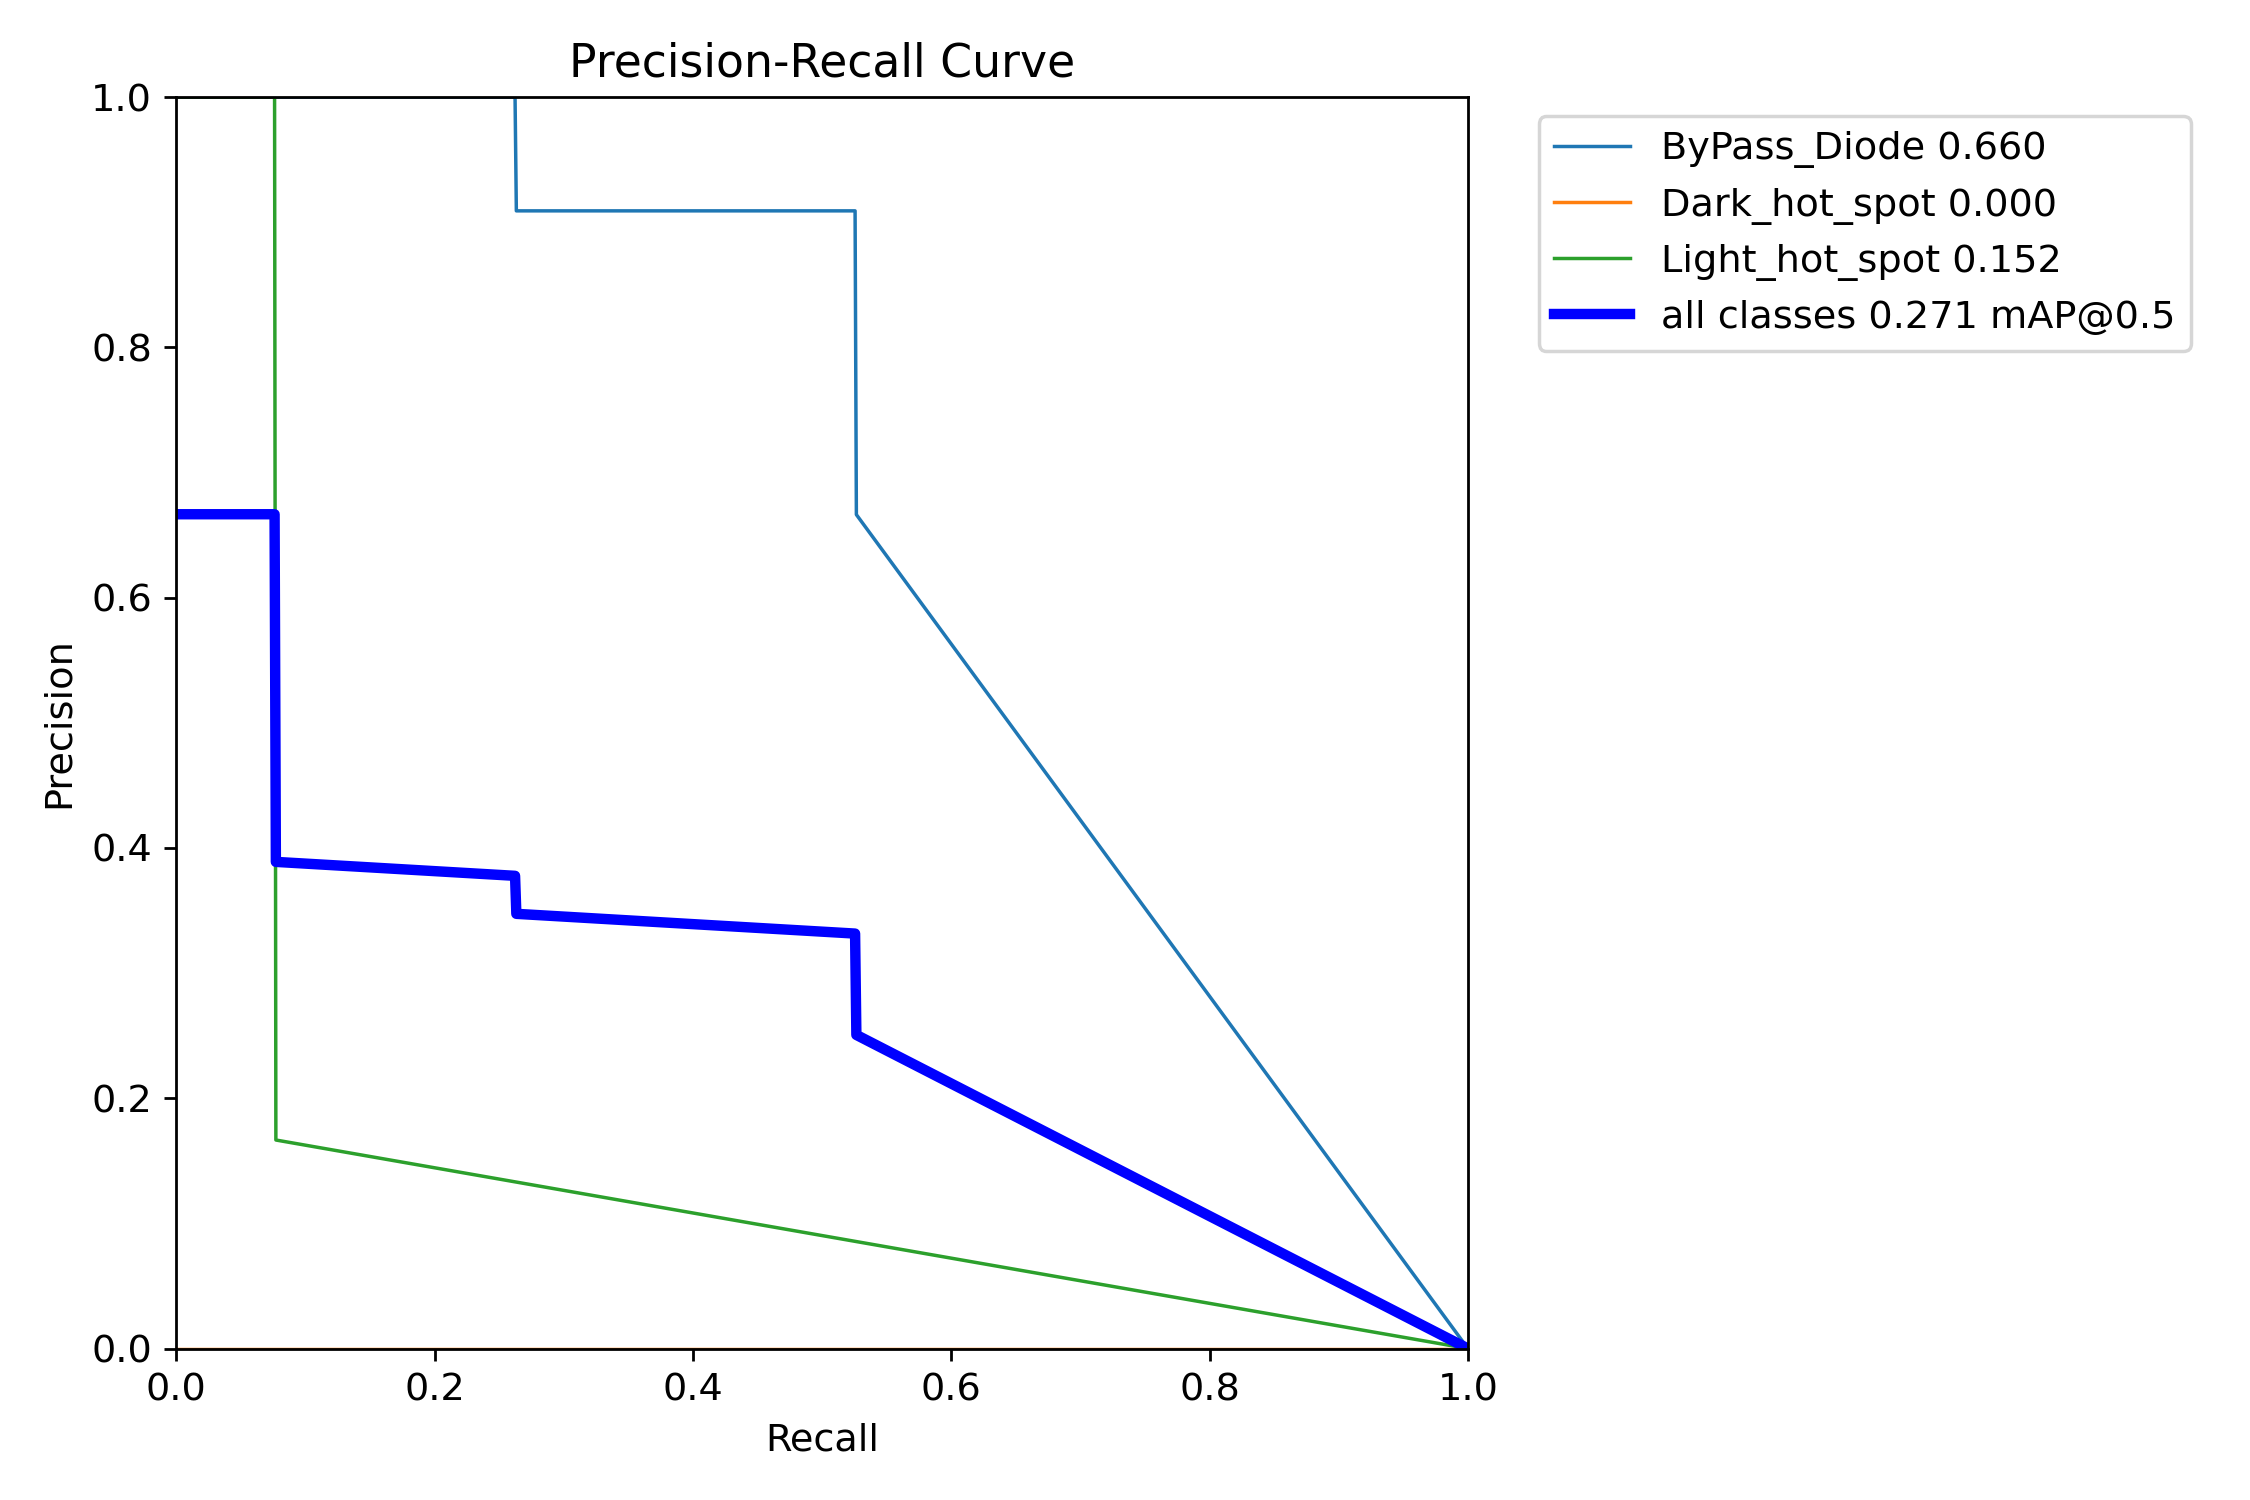

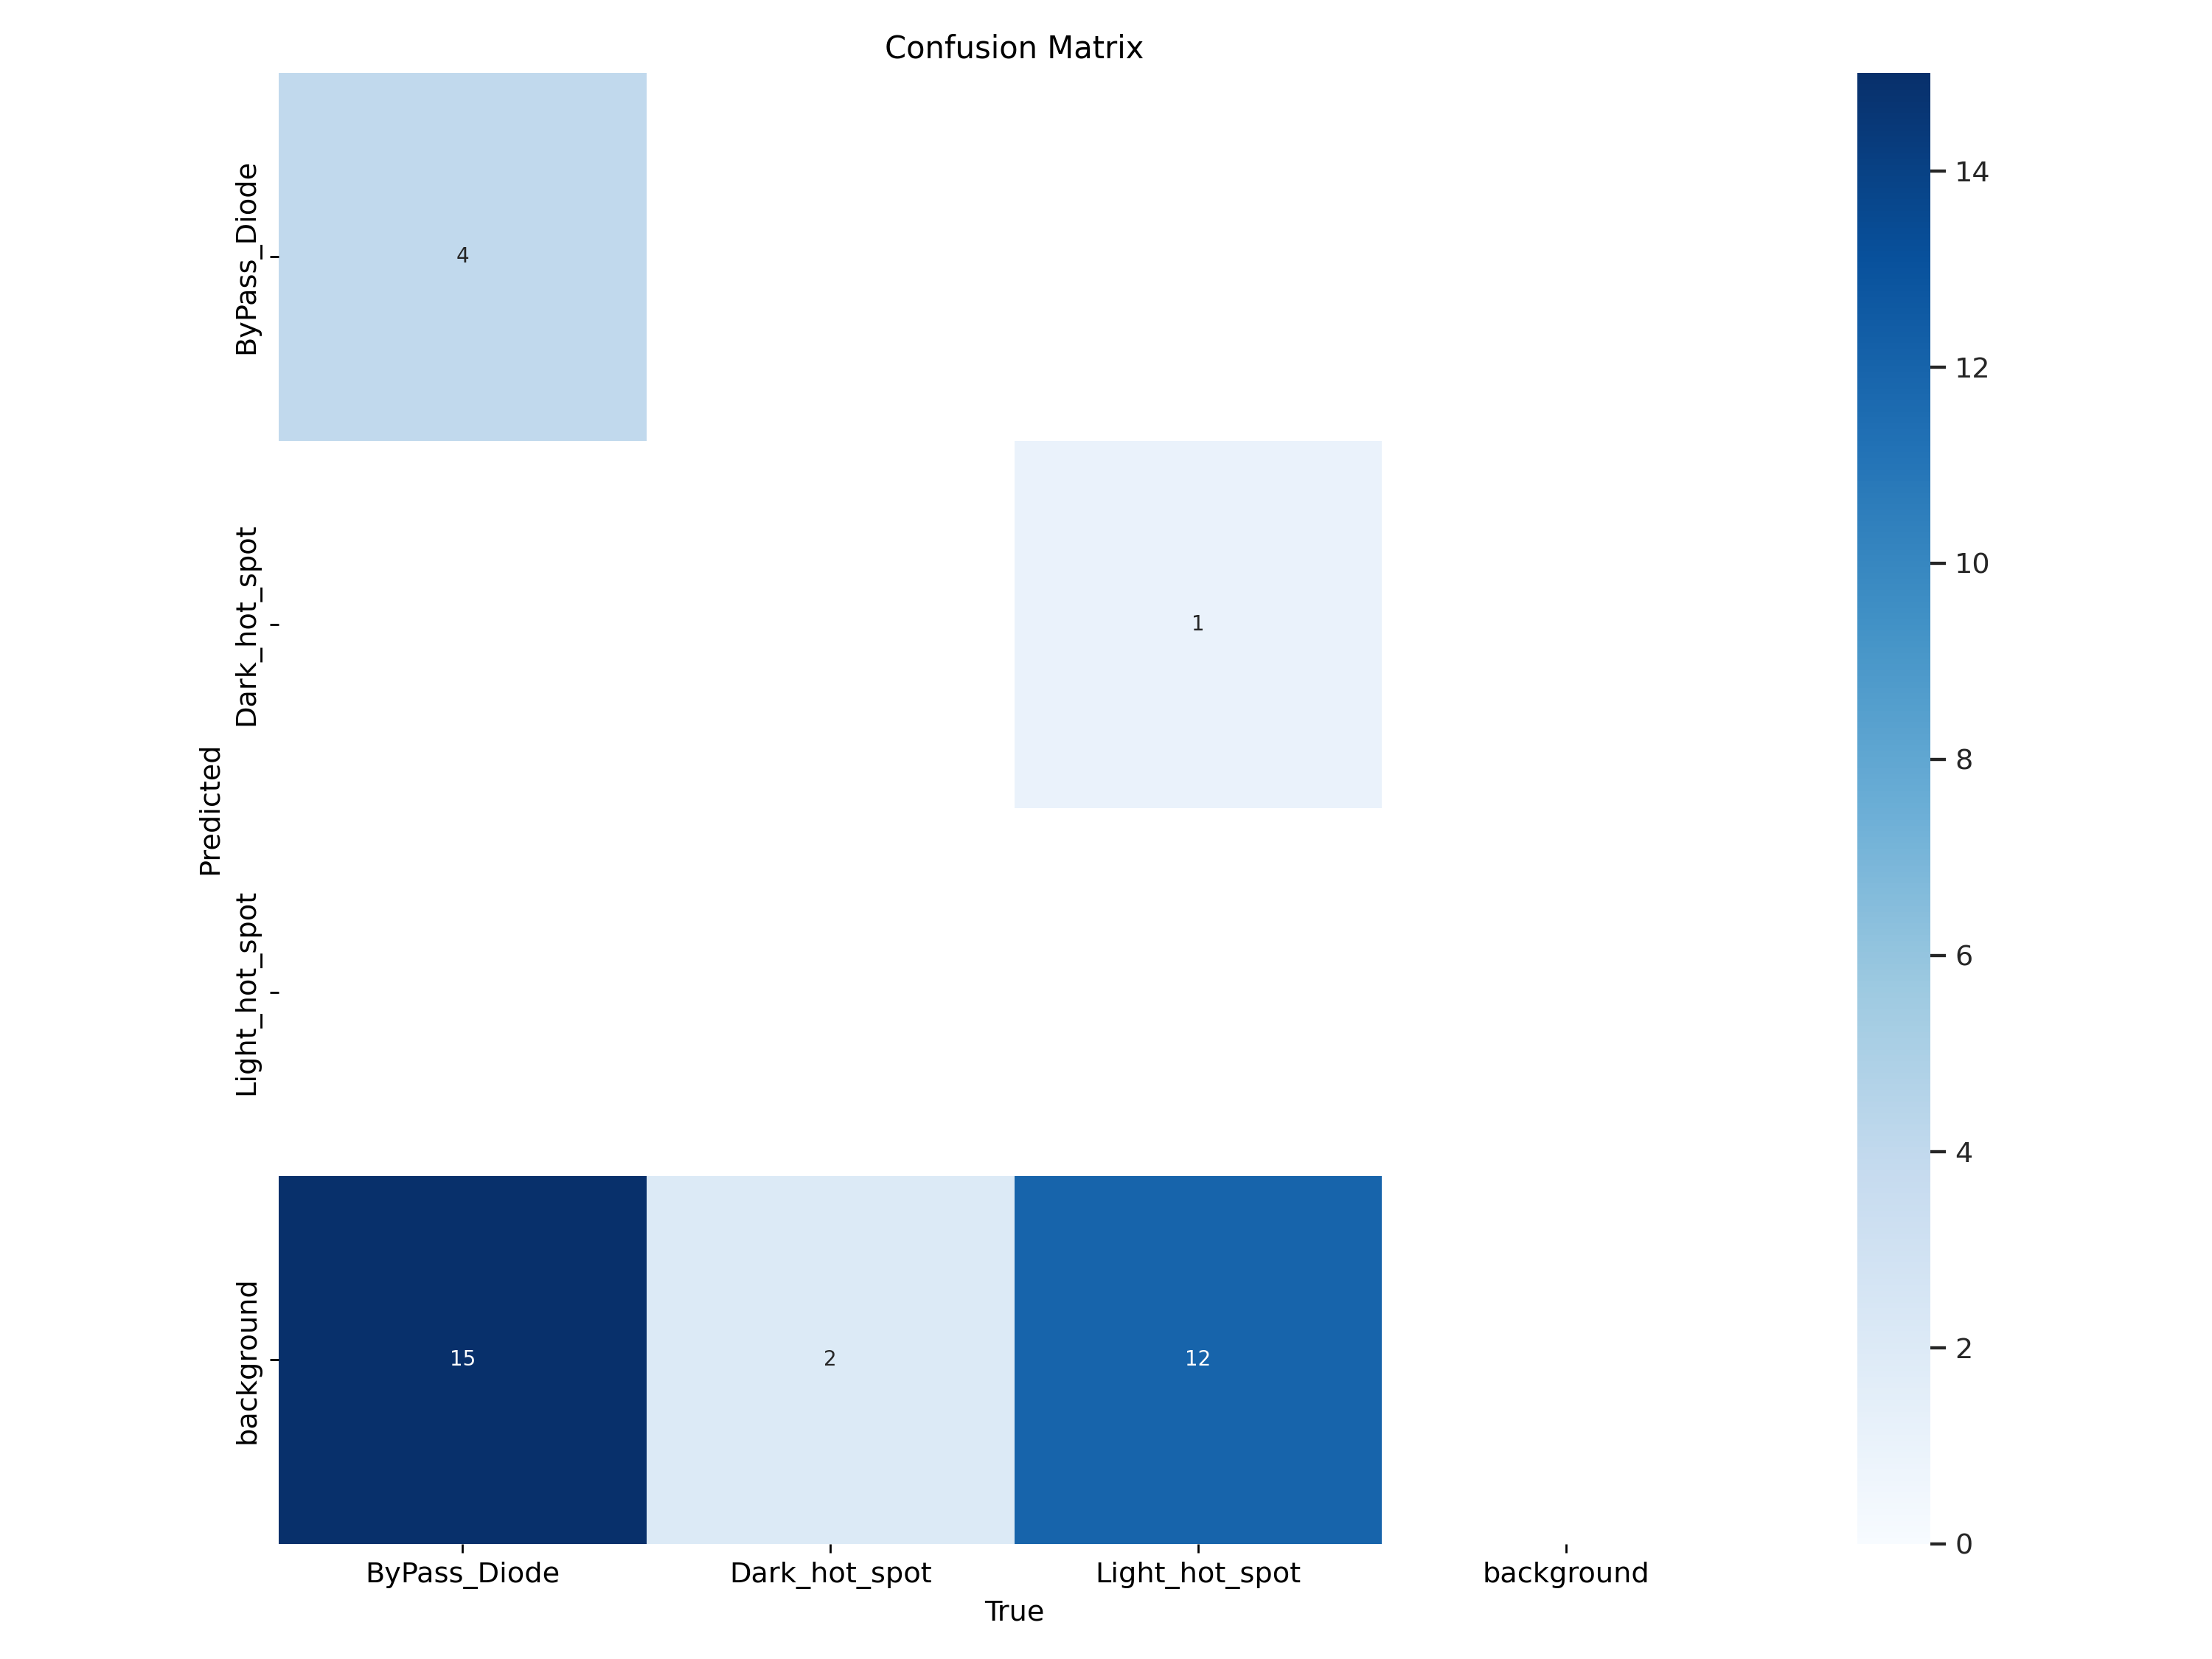

In [19]:
from IPython.display import Image
from IPython.display import display
x = Image(filename='runs/detect/train/F1_curve.png')
y = Image(filename='runs/detect/train/PR_curve.png')
z = Image(filename='runs/detect/train/confusion_matrix.png')
display(x, y,z)

Vamos observar as imagens usadas no primeiro lote de treinamento:

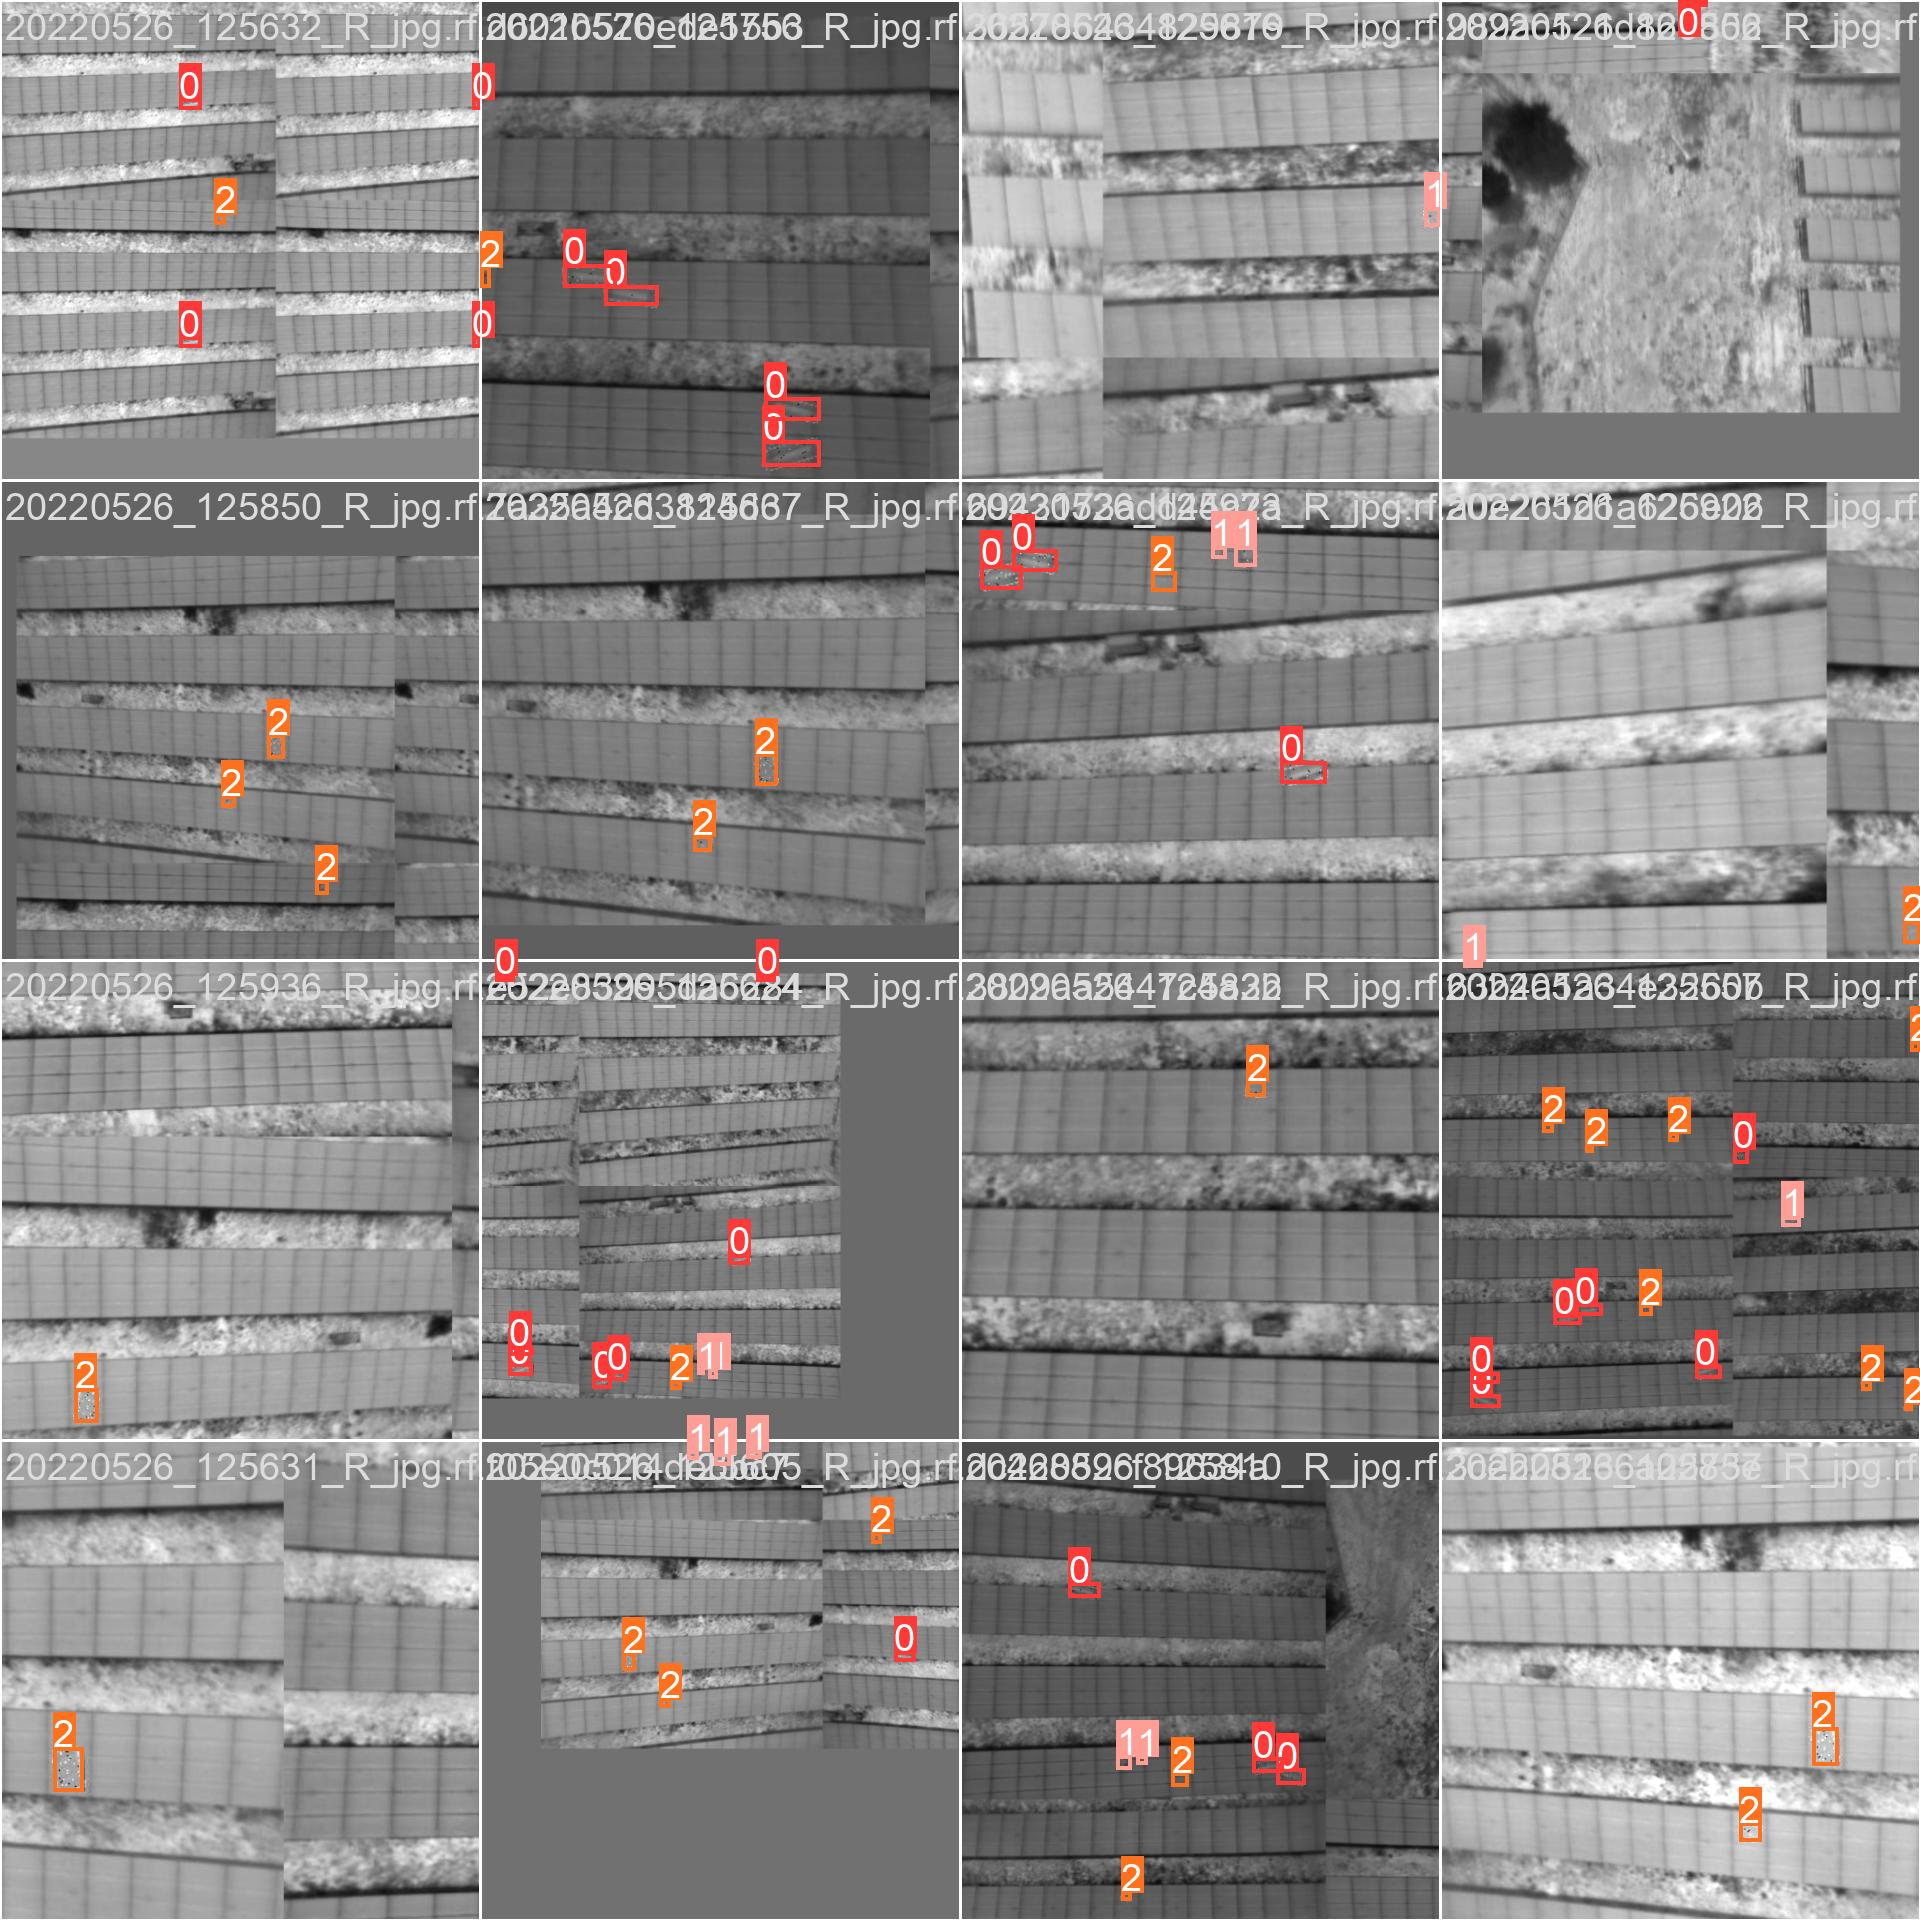

In [20]:
Image(filename=f'/content/runs/detect/train/train_batch0.jpg', width=600)

Depois de treinada, podemos aplicar os pesos para realizar as predições:

In [21]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"
!ls

drive  letuce_data  runs  sample_data  yolov8n.pt  yolov8x.pt


In [22]:
!yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.10 source= "/content/letuce_data/valid/images" save=True save_txt=True

Ultralytics YOLOv8.0.202 🚀 Python-3.10.12 torch-2.1.0+cu118 CUDA:0 (Tesla V100-SXM2-16GB, 16151MiB)
Model summary (fused): 268 layers, 68126457 parameters, 0 gradients, 257.4 GFLOPs

image 1/19 /content/letuce_data/valid/images/20220526_125545_R_jpg.rf.09c235fe2c5b806ccc8a95459cf6963e.jpg: 416x512 1 ByPass_Diode, 1 Dark_hot_spot, 54.0ms
image 2/19 /content/letuce_data/valid/images/20220526_125552_R_jpg.rf.a9ca09313a509bc37b6f8ae20b1a52f6.jpg: 416x512 (no detections), 13.4ms
image 3/19 /content/letuce_data/valid/images/20220526_125555_R_jpg.rf.6945bdbb094f21ee45ac957c73e41ce9.jpg: 416x512 2 ByPass_Diodes, 13.2ms
image 4/19 /content/letuce_data/valid/images/20220526_125601_R_jpg.rf.84e5e7ea8d840f7cb332eb41cbf49e36.jpg: 416x512 (no detections), 13.3ms
image 5/19 /content/letuce_data/valid/images/20220526_125626_R_jpg.rf.5d315dd9d2171eec3cbc7c78078b6df4.jpg: 416x512 1 Dark_hot_spot, 13.3ms
image 6/19 /content/letuce_data/valid/images/20220526_125629_R_jpg.rf.bbee714cf024eafdaeab6a1ee894453

Vamos ver os resultados:

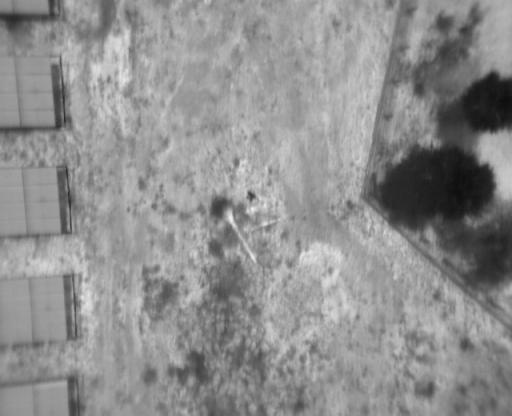

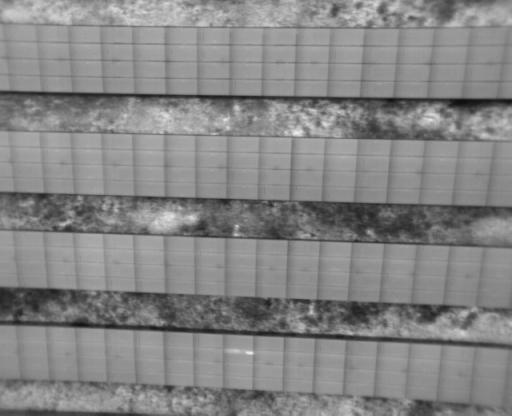

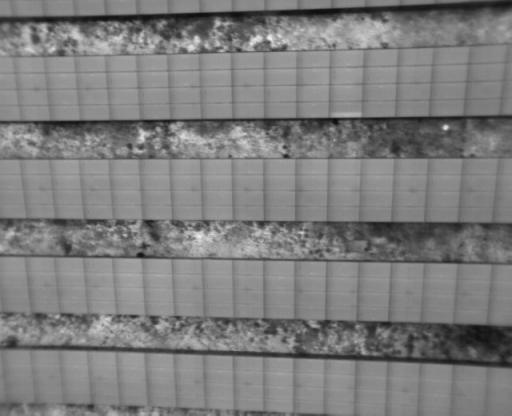

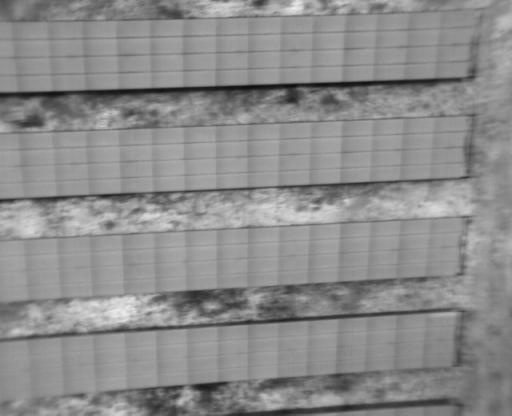

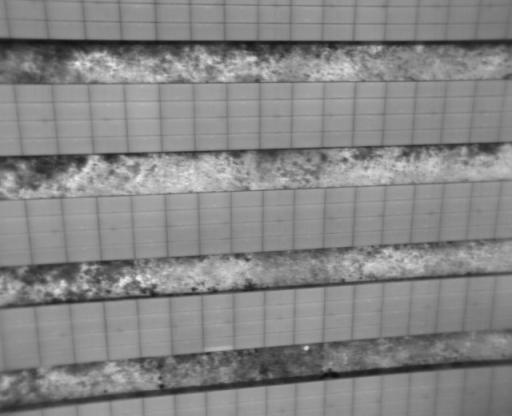

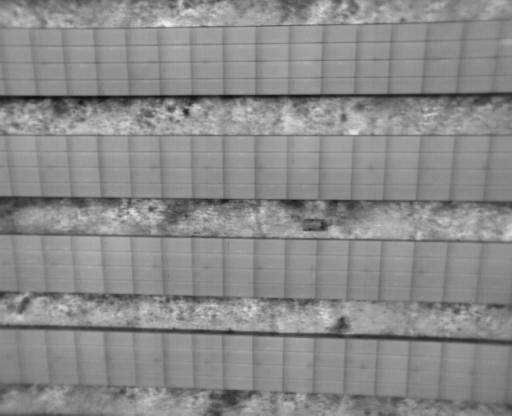

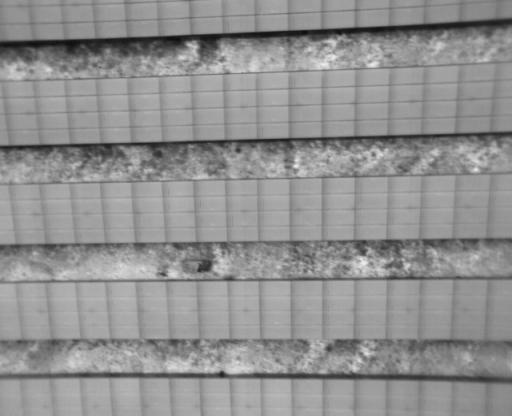

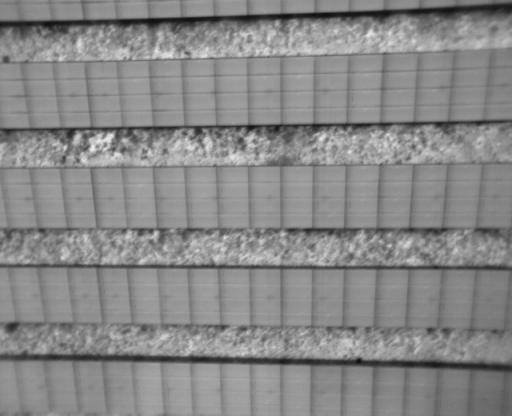

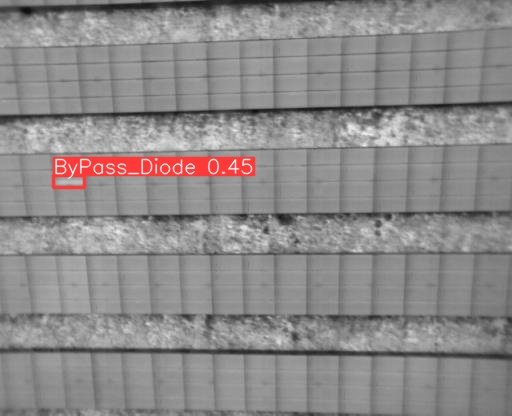

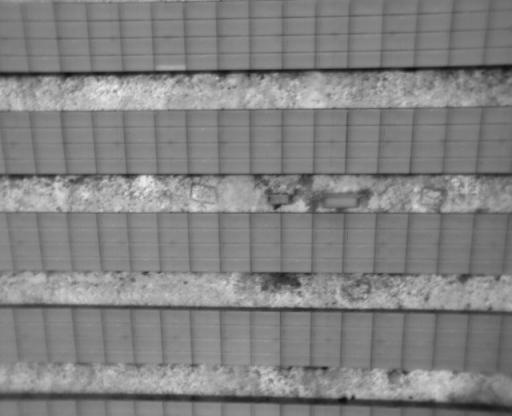

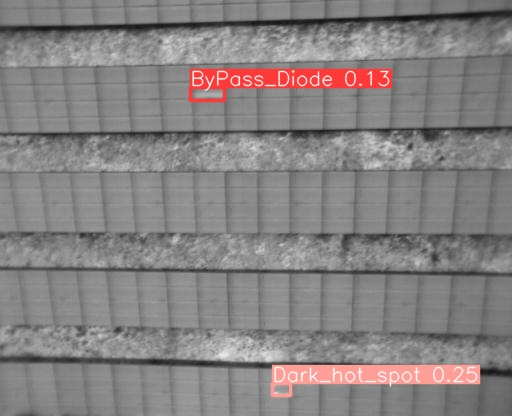

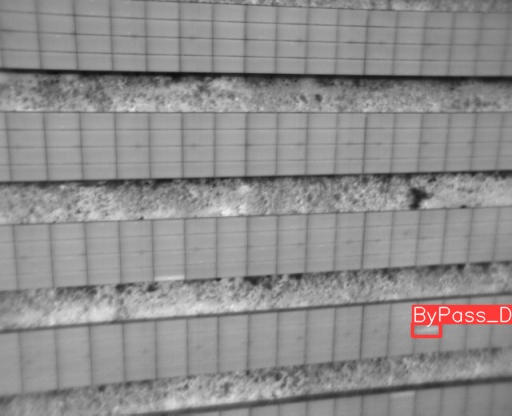

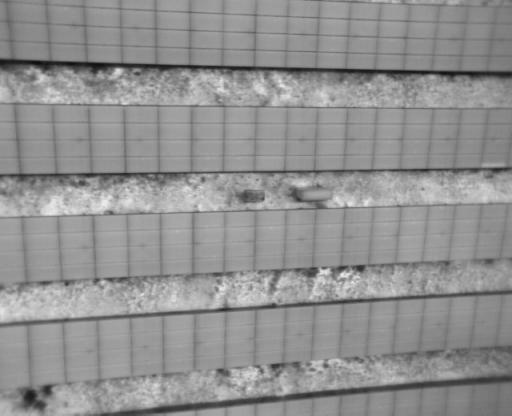

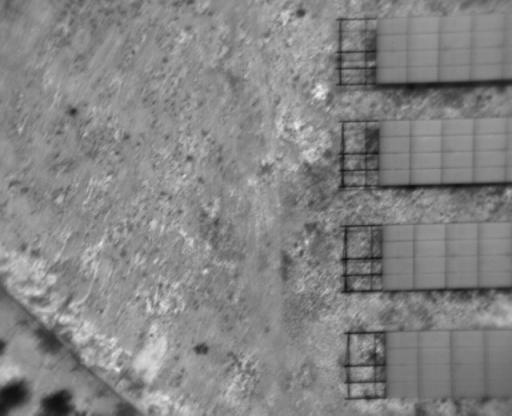

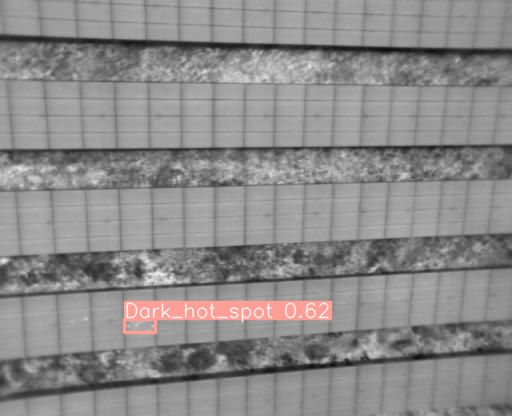

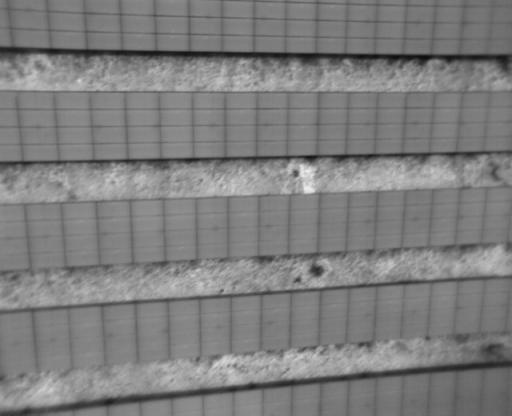

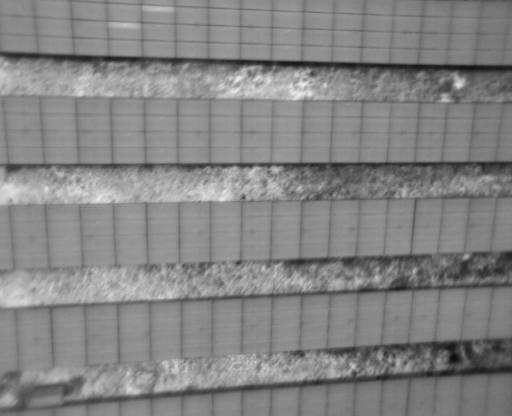

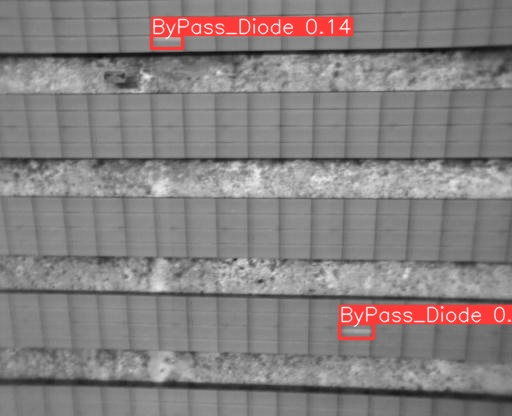

In [24]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:18]:
      display(Image(filename=image_path, width=600))
      print("\n")